In [64]:
import hashlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.combine import SMOTEENN
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Zadanie 1.1: Pobranie danych i EDA

In [65]:
openml_data = fetch_openml(data_id=40536, as_frame=True, parser="auto")
df_raw = openml_data.data.copy()
df_raw["match"] = openml_data.target.astype(int)

print(f"Zbiór: {df_raw.shape[0]} rekordów, {df_raw.shape[1]} cech")

Zbiór: 8378 rekordów, 121 cech


match
brak matcha    6998
match          1380
Name: count, dtype: int64
Udział klasy pozytywnej: 16.5%


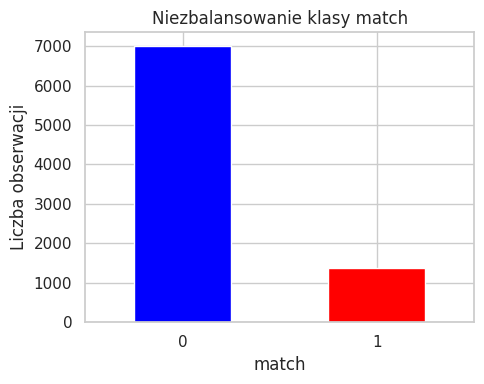

In [66]:
match_counts = df_raw["match"].value_counts().sort_index()
print(match_counts.rename({0: "brak matcha", 1: "match"}))
print(f"Udział klasy pozytywnej: {match_counts[1] / len(df_raw):.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
match_counts.plot(kind="bar", ax=ax, color=["blue", "red"])
ax.set_title("Niezbalansowanie klasy match")
ax.set_xlabel("match")
ax.set_ylabel("Liczba obserwacji")
ax.set_xticklabels(["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

In [67]:
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Top kolumn z brakami:")
display(missing.head(8).to_frame("liczba_NaN"))


Top kolumn z brakami:


,liczba_NaN
expected_num_interested_in_me,6578
expected_num_matches,1173
shared_interests_o,1076
shared_interests_partner,1067
ambitous_o,722
ambition_partner,712
met,375
funny_o,360


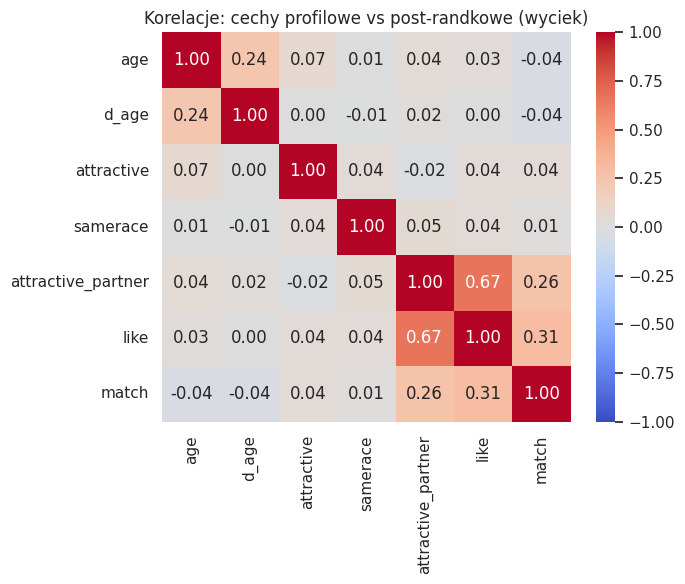

In [68]:
numeric_for_corr = [
    "age", "d_age", "attractive", "samerace",
    "attractive_partner", "like", "match",
]
corr = df_raw[numeric_for_corr].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Korelacje: cechy profilowe vs post-randkowe (wyciek)")
plt.tight_layout()
plt.show()

## Zadanie 1.2: Przygotowanie danych

In [69]:
LEAKAGE_COLS = [
    "has_null",

    "attractive_o", "sinsere_o", "intelligence_o", "funny_o", "ambitous_o", "shared_interests_o",
    "d_attractive_o", "d_sinsere_o", "d_intelligence_o", "d_funny_o", "d_ambitous_o", "d_shared_interests_o",

    "attractive_partner", "sincere_partner", "intelligence_partner", "funny_partner",
    "ambition_partner", "shared_interests_partner",
    "d_attractive_partner", "d_sincere_partner", "d_intelligence_partner", "d_funny_partner",
    "d_ambition_partner", "d_shared_interests_partner",

    "interests_correlate", "d_interests_correlate",
    "like", "guess_prob_liked", "d_like", "d_guess_prob_liked",
]

df = df_raw.drop(columns=[c for c in LEAKAGE_COLS if c in df_raw.columns])
y = df["match"].copy()
X_full = df.drop(columns=["match"])

print(f"Po usunięciu wycieków: {X_full.shape[1]} cech, {len(X_full)} wierszy")

Po usunięciu wycieków: 89 cech, 8378 wierszy


In [70]:
ID_COLS = [
    "gender", "age", "race", "field",
    "attractive", "sincere", "intelligence", "funny", "ambition",
    "attractive_important", "sincere_important", "intellicence_important",
    "funny_important", "ambtition_important", "shared_interests_important",
]


def make_user_fingerprint(row: pd.Series) -> str:
    payload = "|".join(str(row[col]) for col in ID_COLS)
    return hashlib.md5(payload.encode()).hexdigest()


user_id = X_full[ID_COLS].apply(make_user_fingerprint, axis=1)
print(f"Liczba profili: {user_id.nunique()}")
print(user_id.value_counts().describe())

Liczba profili: 547
count    547.000000
mean      15.316271
std        5.134507
min        5.000000
25%       10.000000
50%       16.000000
75%       20.000000
max       43.000000
Name: count, dtype: float64


In [71]:
TEST_SAMPLES_PER_USER = 5
TEST_USER_FRACTION = 0.20

rng = np.random.RandomState(RANDOM_STATE)
user_counts = user_id.value_counts()
eligible_users = user_counts[user_counts >= TEST_SAMPLES_PER_USER].index
n_test_users = max(1, int(len(eligible_users) * TEST_USER_FRACTION))
test_users = rng.choice(eligible_users, size=n_test_users, replace=False)

train_indices, test_indices = [], []
for uid, group_idx in user_id.groupby(user_id).groups.items():
    idx = list(group_idx)
    if uid in test_users:
        chosen = rng.choice(idx, size=TEST_SAMPLES_PER_USER, replace=False)
        test_indices.extend(chosen)
        train_indices.extend([i for i in idx if i not in chosen])
    else:
        train_indices.extend(idx)

X_train = X_full.loc[train_indices].copy()
X_test = X_full.loc[test_indices].copy()
y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

user_id_train = user_id.loc[train_indices]
user_id_test = user_id.loc[test_indices]

assert "user_id" not in X_train.columns
assert "user_id" not in X_test.columns

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Użytkownicy testowi: {len(test_users)}")
print(f"Próbki na użytkownika w teście (unikalne): {user_id_test.value_counts().unique()}")
print(f"Match rate train/test: {y_train.mean():.3f} / {y_test.mean():.3f}")

Train: 7833, Test: 545
Użytkownicy testowi: 109
Próbki na użytkownika w teście (unikalne): [5]
Match rate train/test: 0.164 / 0.176


## Zadanie 1.3: Model bazowy i wizualizacja problemu

In [72]:
def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["age_diff_abs"] = pd.to_numeric(out["d_age"], errors="coerce").abs()
    out["attract_self_minus_partner_pref"] = (
        pd.to_numeric(out["attractive"], errors="coerce")
        - pd.to_numeric(out["pref_o_attractive"], errors="coerce")
    )
    out["importance_race_gap"] = (
        pd.to_numeric(out["importance_same_race"], errors="coerce")
        - pd.to_numeric(out["d_importance_same_race"], errors="coerce")
    )
    interest_cols = [
        "sports", "exercise", "dining", "museums", "art", "hiking",
        "gaming", "clubbing", "reading", "movies", "concerts", "music",
    ]
    partner_cols = [f"d_{c}" for c in interest_cols]
    self_vals = out[interest_cols].apply(pd.to_numeric, errors="coerce")
    partner_vals = out[partner_cols].apply(pd.to_numeric, errors="coerce")
    out["interests_l1_distance"] = (self_vals.values - partner_vals.values).sum(axis=1)
    return out


X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

cat_cols = X_train_fe.select_dtypes(include=["category", "object"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                    ),
                ),
            ]),
            cat_cols,
        ),
    ]
)

print(f"Cechy numeryczne: {len(num_cols)}, kategoryczne: {len(cat_cols)}")

Cechy numeryczne: 48, kategoryczne: 45


In [73]:
naive_majority = Pipeline([
    ("pre", preprocessor),
    ("clf", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
])
naive_random = Pipeline([
    ("pre", preprocessor),
    ("clf", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
])

for name, model in [("Większościowy", naive_majority), ("Losowy (stratyfikowany)", naive_random)]:
    model.fit(X_train_fe, y_train)
    y_pred = model.predict(X_test_fe)
    print(f"\n {name} ")
    print(classification_report_imbalanced(y_test, y_pred))


 Większościowy 
                   pre       rec       spe        f1       geo       iba       sup

          0       0.82      1.00      0.00      0.90      0.00      0.00       449
          1       0.00      0.00      1.00      0.00      0.00      0.00        96

avg / total       0.68      0.82      0.18      0.74      0.00      0.00       545


 Losowy (stratyfikowany) 
                   pre       rec       spe        f1       geo       iba       sup

          0       0.82      0.82      0.18      0.82      0.38      0.15       449
          1       0.17      0.18      0.82      0.17      0.38      0.14        96

avg / total       0.71      0.70      0.29      0.71      0.38      0.15       545



In [74]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
}

baseline_results = {}
for name, estimator in baseline_models.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", estimator)])
    pipe.fit(X_train_fe, y_train)
    y_pred = pipe.predict(X_test_fe)
    baseline_results[name] = pipe
    print(f"\n {name}")
    print(classification_report_imbalanced(y_test, y_pred))


 Logistic Regression
                   pre       rec       spe        f1       geo       iba       sup

          0       0.82      1.00      0.00      0.90      0.00      0.00       449
          1       0.00      0.00      1.00      0.00      0.00      0.00        96

avg / total       0.68      0.82      0.18      0.74      0.00      0.00       545


 Decision Tree
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.97      0.09      0.90      0.30      0.10       449
          1       0.43      0.09      0.97      0.15      0.30      0.08        96

avg / total       0.76      0.82      0.25      0.77      0.30      0.10       545



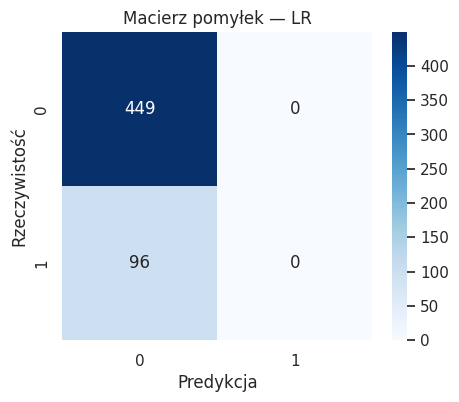

In [75]:
log_reg = baseline_results["Logistic Regression"]
y_pred_lr = log_reg.predict(X_test_fe)
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywistość")
plt.title("Macierz pomyłek — LR")
plt.show()

## Zadanie 1.4: Techniki resamplingu

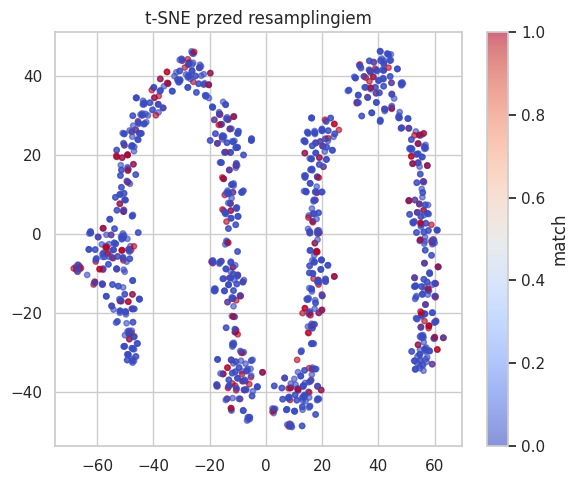

In [76]:
TSNE_SAMPLES = 1500

pre_only = Pipeline([("pre", preprocessor)])
X_train_proc = pre_only.fit_transform(X_train_fe, y_train)

if len(X_train_proc) > TSNE_SAMPLES:
    sample_idx = rng.choice(len(X_train_proc), size=TSNE_SAMPLES, replace=False)
    X_tsne_input = X_train_proc[sample_idx]
    y_tsne = y_train.iloc[sample_idx].values
else:
    X_tsne_input = X_train_proc
    y_tsne = y_train.values

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca")
X_tsne_orig = tsne.fit_transform(X_tsne_input)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_tsne_orig[:, 0], X_tsne_orig[:, 1], c=y_tsne, cmap="coolwarm", alpha=0.6, s=15)
plt.title("t-SNE przed resamplingiem")
plt.colorbar(scatter, label="match")
plt.tight_layout()
plt.show()

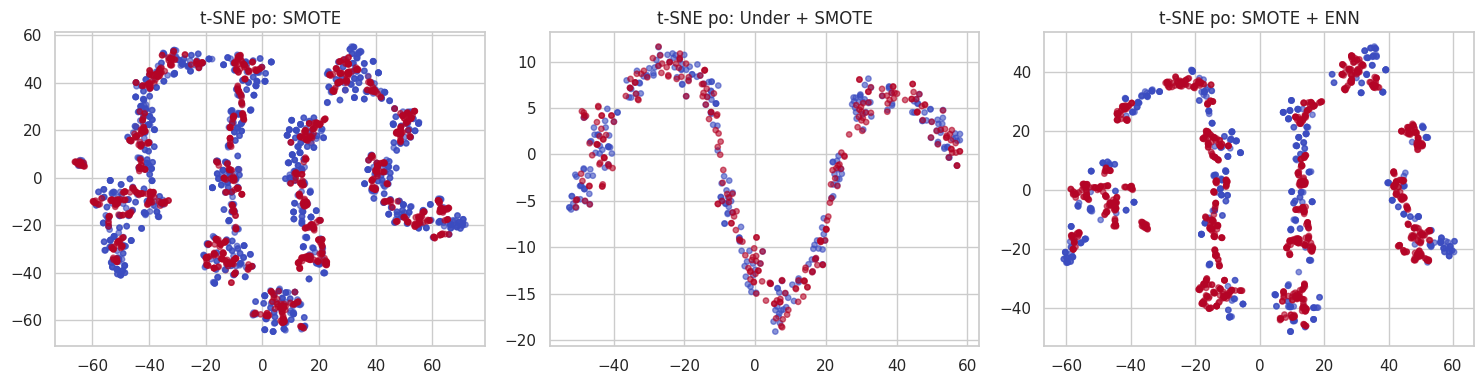

,recall,precision,f1,roc_auc
SMOTE,0.625,0.283,0.390,0.674
Under + SMOTE,0.625,0.265,0.373,0.669
SMOTE + ENN,0.760,0.247,0.372,0.678


In [77]:
resamplers_tsne = {
    "SMOTE": SMOTE(random_state=RANDOM_STATE),
    "Under + SMOTE": ImbPipeline([
        ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
    ]),
    "SMOTE + ENN": SMOTEENN(random_state=RANDOM_STATE),
}

resampler_model_steps = {
    "SMOTE": [("sampler", SMOTE(random_state=RANDOM_STATE))],
    "Under + SMOTE": [
        ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
    ],
    "SMOTE + ENN": [("sampler", SMOTEENN(random_state=RANDOM_STATE))],
}

fig, axes = plt.subplots(1, len(resamplers_tsne), figsize=(15, 4))
if len(resamplers_tsne) == 1:
    axes = [axes]

resampling_reports = {}
for ax, (name, sampler) in zip(axes, resamplers_tsne.items()):
    X_res, y_res = sampler.fit_resample(X_tsne_input, y_tsne)
    X_tsne_res = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca").fit_transform(X_res)

    sc = ax.scatter(X_tsne_res[:, 0], X_tsne_res[:, 1], c=y_res, cmap="coolwarm", alpha=0.6, s=15)
    ax.set_title(f"t-SNE po: {name}")

    model = ImbPipeline(
        [("pre", preprocessor)]
        + resampler_model_steps[name]
        + [("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))]
    )
    model.fit(X_train_fe, y_train)
    y_pred = model.predict(X_test_fe)
    resampling_reports[name] = {
        "recall": recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, model.predict_proba(X_test_fe)[:, 1]),
    }

plt.tight_layout()
plt.show()

display(pd.DataFrame(resampling_reports).T.round(3))

## Zadanie 1.5: Modele ensemble dla danych niezbalansowanych

In [78]:
ensemble_models = {
    "LogReg (bez resamplingu)": Pipeline([
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    "RF class_weight=balanced": Pipeline([
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
    "BalancedRandomForest": Pipeline([
        ("pre", preprocessor),
        ("clf", BalancedRandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "EasyEnsemble": Pipeline([
        ("pre", preprocessor),
        ("clf", EasyEnsembleClassifier(n_estimators=10, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

ensemble_probs = {}
ensemble_metrics = {}

for name, model in ensemble_models.items():
    model.fit(X_train_fe, y_train)
    proba = model.predict_proba(X_test_fe)[:, 1]
    y_pred = (proba >= 0.5).astype(int)
    ensemble_probs[name] = proba
    ensemble_metrics[name] = {
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC (AP)": average_precision_score(y_test, proba),
    }

display(pd.DataFrame(ensemble_metrics).T.round(3))

,Recall,Precision,F1,ROC-AUC,PR-AUC (AP)
LogReg (bez resamplingu),0.000,0.000,0.000,0.670,0.321
RF class_weight=balanced,0.281,0.429,0.340,0.665,0.350
BalancedRandomForest,0.396,0.342,0.367,0.681,0.370
EasyEnsemble,0.635,0.284,0.392,0.682,0.348


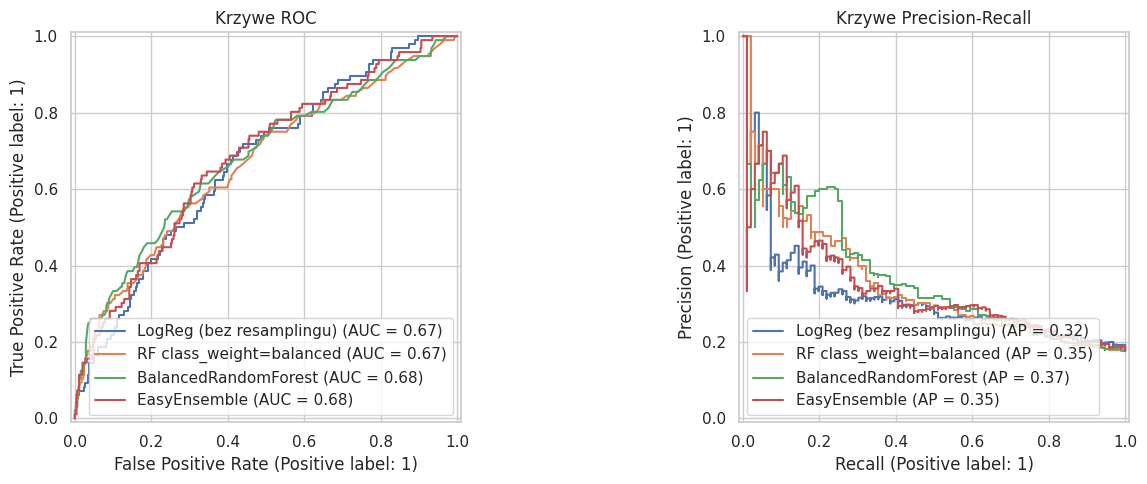

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in ensemble_probs.items():
    RocCurveDisplay.from_predictions(y_test, proba, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[1], name=name)

axes[0].set_title("Krzywe ROC")
axes[1].set_title("Krzywe Precision-Recall")
plt.tight_layout()
plt.show()

## Zadanie 2.1: Ewaluacja w kontekście aplikacji

In [80]:
ranking_model = ensemble_models["BalancedRandomForest"]
ranking_model.fit(X_train_fe, y_train)
test_proba = ranking_model.predict_proba(X_test_fe)[:, 1]

ranking_df = pd.DataFrame({
    "user_id": user_id_test.values,
    "y_true": y_test.values,
    "score": test_proba,
})


def precision_k(group: pd.DataFrame, k: int) -> float:
    top_k = group.nlargest(k, "score")
    if len(top_k) == 0:
        return 0.0
    return top_k["y_true"].mean()


def mean_reciprocal_rank(group: pd.DataFrame) -> float:
    ordered = group.sort_values("score", ascending=False)
    hits = ordered[ordered["y_true"] == 1]
    if hits.empty:
        return 0.0
    first_rank = ordered.index.get_loc(hits.index[0]) + 1
    return 1.0 / first_rank


K_VALUES = [1, 3, 5, 7]
per_user_metrics = []
for uid, group in ranking_df.groupby("user_id"):
    row = {"user_id": uid, "MRR": mean_reciprocal_rank(group)}
    for k in K_VALUES:
        row[f"Precision@{k}"] = precision_k(group, k)
    per_user_metrics.append(row)

rec_metrics = pd.DataFrame(per_user_metrics).mean(numeric_only=True)
display(rec_metrics.round(3))

MRR            0.343
Precision@1    0.211
Precision@3    0.183
Precision@5    0.176
Precision@7    0.176
dtype: float64

## Zadanie 2.2: Strategia „Model Romantyczny”

In [81]:
romantic_base = Pipeline([
    ("pre", preprocessor),
    ("clf", BalancedRandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_fe, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)
romantic_base.fit(X_tr, y_tr)
val_proba = romantic_base.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)

best_t, best_recall = 0.5, -1
for t in thresholds:
    r = recall_score(y_val, (val_proba >= t).astype(int))
    if r > best_recall:
        best_recall, best_t = r, t

romantic_threshold = best_t
romantic_base.fit(X_train_fe, y_train)
romantic_proba = romantic_base.predict_proba(X_test_fe)[:, 1]
romantic_pred = (romantic_proba >= romantic_threshold).astype(int)

print(f"Próg romantyczny: {romantic_threshold:.2f}")
print(classification_report(y_test, romantic_pred, digits=3))

Próg romantyczny: 0.05
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       449
           1      0.176     1.000     0.300        96

    accuracy                          0.176       545
   macro avg      0.088     0.500     0.150       545
weighted avg      0.031     0.176     0.053       545



## Zadanie 2.3: Strategia „Model Biznesowy”

In [82]:
COST_MATRIX = {
    "TN": 0,  # Poprawny brak polecenia - brak kosztu
    "TP": +2, # Zadowolony klient, pozytywna recenzja
    "FP": -8, # Złe polecenie - niezadowolony użytkownik, zła recenzja
    "FN": -3, # Przeoczony match - utracona szansa, ale mniej widoczna dla użytkownika
}

In [83]:
def total_cost(y_true: np.ndarray, y_pred: np.ndarray, costs: dict) -> float:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (
        costs["TN"] * tn
        + costs["TP"] * tp
        + costs["FP"] * fp
        + costs["FN"] * fn
    )

business_base = Pipeline([
    ("pre", preprocessor),
    ("clf", BalancedRandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])
business_base.fit(X_tr, y_tr)
val_proba_b = business_base.predict_proba(X_val)[:, 1]

best_cost, business_threshold = -np.inf, 0.5
for t in thresholds:
    pred = (val_proba_b >= t).astype(int)
    c = total_cost(y_val.values, pred, COST_MATRIX)
    if c > best_cost: 
        best_cost, business_threshold = c, t

business_base.fit(X_train_fe, y_train)
business_proba = business_base.predict_proba(X_test_fe)[:, 1]
business_pred = (business_proba >= business_threshold).astype(int)

print(f"Próg biznesowy: {business_threshold:.2f}")
print(classification_report(y_test, business_pred, digits=3))
print(f"Koszt na zbiorze testowym: {total_cost(y_test.values, business_pred, COST_MATRIX)}")

Próg biznesowy: 0.90
              precision    recall  f1-score   support

           0      0.824     1.000     0.903       449
           1      0.000     0.000     0.000        96

    accuracy                          0.824       545
   macro avg      0.412     0.500     0.452       545
weighted avg      0.679     0.824     0.744       545

Koszt na zbiorze testowym: -288


## Zadanie 2.4: Podsumowanie wyników

In [84]:
def model_summary(name: str, y_true, y_pred, proba, threshold, costs) -> dict:
    return {
        "Model": name,
        "Threshold": threshold,
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        "Koszt łączny": total_cost(y_true.values, y_pred, costs),
    }


summary_df = pd.DataFrame([
    model_summary(
        "Model romantyczny", y_test, romantic_pred, romantic_proba,
        romantic_threshold, COST_MATRIX,
    ),
    model_summary(
        "Model biznesowy", y_test, business_pred, business_proba,
        business_threshold, COST_MATRIX,
    ),
]).set_index("Model")

display(summary_df.round(3))

,Threshold,Recall,Precision,F1,ROC-AUC,PR-AUC,Koszt łączny
Model,,,,,,,
Model romantyczny,0.05,1.0,0.176,0.3,0.675,0.369,-3400
Model biznesowy,0.90,0.0,0.000,0.0,0.675,0.369,-288


Różnica (romantyczny - biznesowy):


Threshold         -0.850
Recall             1.000
Precision          0.176
F1                 0.300
ROC-AUC            0.000
PR-AUC             0.000
Koszt łączny   -3112.000
dtype: float64

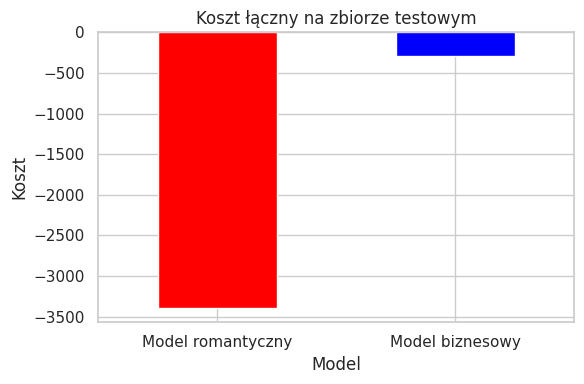

In [85]:

delta = summary_df.loc["Model romantyczny"] - summary_df.loc["Model biznesowy"]
print("Różnica (romantyczny - biznesowy):")
display(delta.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
summary_df["Koszt łączny"].plot(kind="bar", ax=ax, color=["RED", "BLUE"])
ax.set_title("Koszt łączny na zbiorze testowym")
ax.set_ylabel("Koszt")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()